# 🧠 BERT for Mental Health State Classification  

This notebook is my **first project using Hugging Face Transformers**. I am currently learning and exploring how to fine-tune BERT for text classification. 

---

## 🔎 Project Overview  
The goal of this project is to classify mental health states based on short text statements. After preprocessing and balancing the dataset, the model predicts one of the following classes:

- **Normal**  
- **Depression**  
- **Suicidal**  
- **Anxiety**  
- **Stress**  
- **Bipolar**  
- **Personality disorder**

---

## ⚙️ Data Preprocessing  
- Dropped unnecessary columns (`Unnamed: 0`)  
- Removed null values using `dropna`  
- Performed text cleaning (lowercasing, removing special characters, stopword removal)  
- Balanced the dataset using **RandomOverSampler** from `imblearn`  
- Encoded class labels with **LabelEncoder**  
- Tokenized text with **BERT tokenizer**  

---

## 🤖 Model Building  
- Model: **BERT (bert-base-uncased)** fine-tuned for sequence classification  
- Used **Hugging Face Trainer** with training arguments (learning rate, epochs, batch size, etc.)  
- Evaluation performed with classification report and confusion matrix  

---

## 📊 Results  
The model provides predictions across all 7 classes and performance is evaluated with standard metrics (precision, recall, F1-score) and confusion matrix visualization.  

---

## 🙌 Note  
This is my **first hands-on project with Transformers and BERT**, built while learning. I followed [this tutorial](https://youtu.be/vDXZJJcLAdI?si=s84iFUPlBWuBCizN) and then applied the steps to my dataset. I would really appreciate **any feedback, suggestions, or improvements** to help me learn better!  


## Import Libraries

In [1]:
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

import pandas as pd
import numpy as np
import transformers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings("ignore")

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 16.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


2025-11-18 09:04:38.137468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763456678.320901      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763456678.372457      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load Data

In [2]:
df = pd.read_csv('/kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv')

In [3]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
df.shape

(53043, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [7]:
df.describe()

,Unnamed: 0
count,53043.000000
mean,26521.000000
std,15312.339501
min,0.000000
25%,13260.500000
50%,26521.000000
75%,39781.500000
max,53042.000000


## Handling Null Values

In [8]:
df.isna().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [11]:
df = df.sample(n=6000, random_state=42).reset_index(drop=True)

In [12]:
df

,statement,status
0,I'm lazy to complain about it ba ihh,Normal
1,i think the wifi on my iphone is broken it wil...,Normal
2,Good tracking apps? I've been trying to find a...,Bipolar
3,I have recently looked into reddit and found t...,Depression
4,that's your favorite thing to do?,Normal
...,...,...
5995,What is around you right now? A photo? A comfo...,Depression
5996,I am tired. I am ready for everything to be ov...,Suicidal
5997,? What if I am at a friends party and a man wh...,Stress
5998,if it add any kind of info m almost the thing ...,Depression


## Data Preprocessing

### Text Cleaning

In [13]:
nltk.download('stopwords')
stopwordss = set(stopwords.words("english")) 

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    words = text.split()
    wordss = [word for word in words if word not in stopwordss]
    return " ".join(words)

df['statement'] = df['statement'].apply(clean_text)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Encoding

In [14]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

## Splitting Data

In [15]:
df.head()

,statement,status,label
0,im lazy to complain about it ba ihh,Normal,3
1,i think the wifi on my iphone is broken it wil...,Normal,3
2,good tracking apps ive been trying to find app...,Bipolar,1
3,i have recently looked into reddit and found t...,Depression,2
4,thats your favorite thing to do,Normal,3


In [16]:
X_train, X_test, y_train, y_test = train_test_split(df[['statement']], df['label'], test_size=0.2, random_state=42)

### Resampling Data

In [17]:
y_train.value_counts()

label
3    1515
2    1361
6     985
0     346
5     249
1     237
4     107
Name: count, dtype: int64

In [18]:
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
print(y_train.value_counts())

label
2    1515
0    1515
3    1515
6    1515
1    1515
5    1515
4    1515
Name: count, dtype: int64


In [19]:
X_train = X_train['statement']
X_test = X_test['statement']

## Tokenization

In [20]:
tokenizer =  BertTokenizer.from_pretrained('bert-base-uncased')

X_train_tokenize = tokenizer(list(X_train), padding=True, truncation=True, max_length=200)
X_test_tokenize = tokenizer(list(X_test), padding=True, truncation=True, max_length=200)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [21]:
print(X_train_tokenize['input_ids'][1])       # first sentence input_ids
print(X_train_tokenize['attention_mask'][0])  # first sentence attention_mask
print(X_train_tokenize['token_type_ids'][0])   # first sentence token_type_ids


[101, 6523, 7941, 8606, 7632, 1045, 2572, 1042, 1998, 2633, 7864, 2000, 2026, 2334, 2752, 2092, 19205, 3070, 2326, 1999, 1996, 2866, 10047, 2025, 11441, 2007, 10089, 2664, 2021, 10047, 2633, 2635, 1996, 4084, 1045, 2342, 2000, 1999, 2344, 2000, 5335, 2026, 3737, 1997, 2166, 1045, 3984, 10047, 2074, 2559, 2005, 2129, 2009, 2573, 1998, 3251, 2009, 3138, 2004, 2146, 2004, 4748, 14945, 6523, 7941, 10047, 2183, 2000, 18420, 2866, 2005, 2008, 2288, 3615, 1999, 2281, 1998, 3403, 2005, 2019, 6098, 2151, 6040, 2052, 2022, 6551, 12315, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 

In [22]:
train_dataset = Dataset.from_dict({
    'input_ids': X_train_tokenize['input_ids'],
    'attention_mask': X_train_tokenize['attention_mask'],
    'labels': list(y_train)   
})

test_dataset = Dataset.from_dict({
    'input_ids': X_test_tokenize['input_ids'],
    'attention_mask': X_test_tokenize['attention_mask'],
    'labels': list(y_test)   
})

## Model Building

In [23]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = len(le.classes_))
training_args = TrainingArguments(
    output_dir="./results",             
    eval_strategy="epoch",        
    save_strategy="epoch",             
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    lr_scheduler_type="linear",
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=3,
    gradient_accumulation_steps=2
)



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
trainer = Trainer(
    model = model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


In [25]:
import wandb
wandb.init(project="Mental Healt State", entity="shivamshukla8112005", mode="offline")

wandb: Tracking run with wandb version 0.20.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.


In [26]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss
1,1.597900,1.473653
2,0.690300,0.816679
3,0.283400,0.695655
4,0.131100,0.609927
5,0.118600,0.666633


TrainOutput(global_step=830, training_loss=0.7212354490555912, metrics={'train_runtime': 1211.269, 'train_samples_per_second': 43.776, 'train_steps_per_second': 0.685, 'total_flos': 5450035169250000.0, 'train_loss': 0.7212354490555912, 'epoch': 5.0})

## Model Evaluation

                      precision    recall  f1-score   support

             Anxiety       0.78      0.83      0.81        83
             Bipolar       0.78      0.70      0.74        56
          Depression       0.77      0.75      0.76       369
              Normal       0.94      0.94      0.94       379
Personality disorder       0.63      0.71      0.67        24
              Stress       0.60      0.75      0.67        55
            Suicidal       0.67      0.65      0.66       234

            accuracy                           0.79      1200
           macro avg       0.74      0.76      0.75      1200
        weighted avg       0.79      0.79      0.79      1200



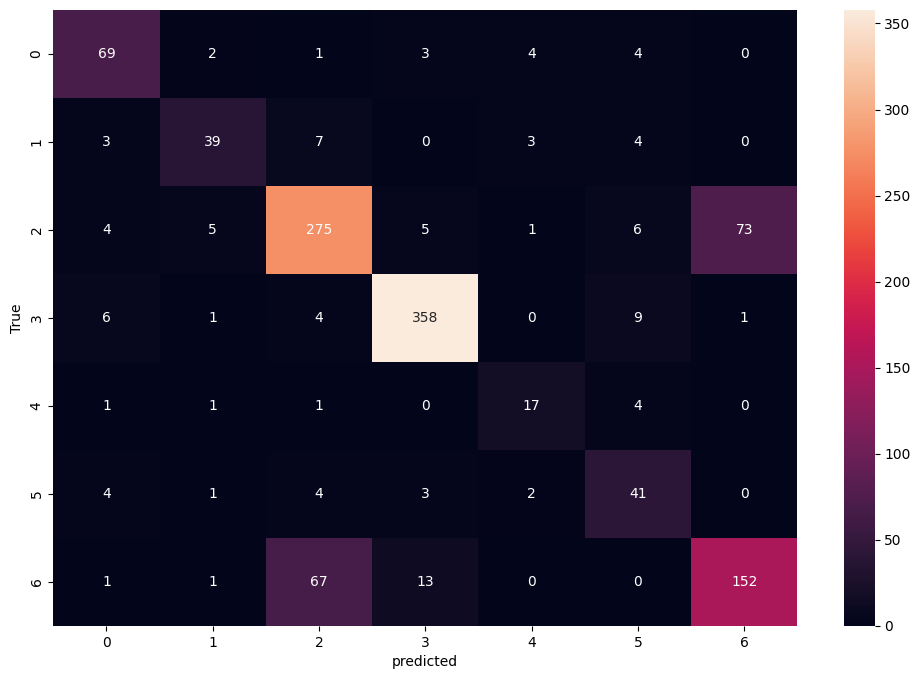

In [27]:
pred, labels, _ = trainer.predict(test_dataset)

predicted_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, predicted_labels, target_names=le.classes_))

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.show()